<a href="https://colab.research.google.com/github/Ahmadfarkhani0805/2025_Pengolahan_Citra_TI-2A/blob/main/JOB5PenCit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Jarak Euclidean antara Patch 1 dan Patch 2: 24.7650
Jarak Euclidean antara Patch 1 dan Patch 3: 5.0000
Jarak Manhattan antara Patch 1 dan Patch 2: 936.4392
Jarak Manhattan antara Patch 1 dan Patch 3: 250.0000


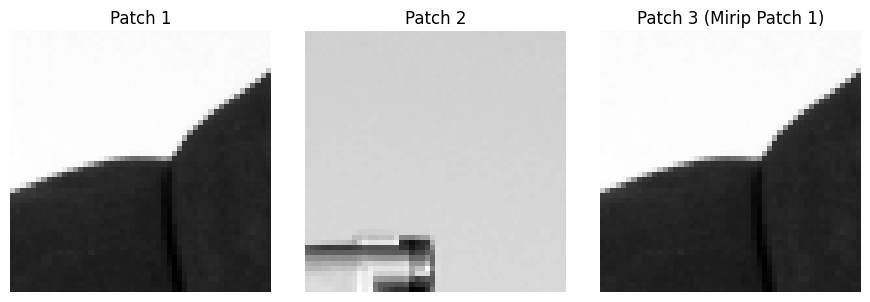

In [1]:
import numpy as np
from skimage import data, img_as_float
from scipy.spatial import distance
import matplotlib.pyplot as plt

# 1. Buat dua patch citra sederhana atau ambil dari citra asli
image = img_as_float(data.camera())
patch1 = image[100:150, 100:150]
patch2 = image[100:150, 300:350]  # Patch dari lokasi berbeda
patch3 = patch1 + 0.1             # Patch1 dengan sedikit noise/perubahan intensitas
patch3 = np.clip(patch3, 0, 1)    # Pastikan nilai tetap di [0, 1]

# 2. Flatten patch menjadi vektor 1D
vec1 = patch1.flatten()
vec2 = patch2.flatten()
vec3 = patch3.flatten()

# 3. Hitung Jarak Euclidean (L2)
dist_l2_12 = distance.euclidean(vec1, vec2)
dist_l2_13 = distance.euclidean(vec1, vec3)

# 4. Hitung Jarak Manhattan (L1)
dist_l1_12 = distance.cityblock(vec1, vec2)
dist_l1_13 = distance.cityblock(vec1, vec3)

# 5. Tampilkan hasil dan patch
print(f"Jarak Euclidean antara Patch 1 dan Patch 2: {dist_l2_12:.4f}")
print(f"Jarak Euclidean antara Patch 1 dan Patch 3: {dist_l2_13:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 2: {dist_l1_12:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 3: {dist_l1_13:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(patch1, cmap='gray')
axes[0].set_title('Patch 1')
axes[0].axis('off')

axes[1].imshow(patch2, cmap='gray')
axes[1].set_title('Patch 2')
axes[1].axis('off')

axes[2].imshow(patch3, cmap='gray')
axes[2].set_title('Patch 3 (Mirip Patch 1)')
axes[2].axis('off')

plt.tight_layout()
plt.show()


Cosine Similarity antara Image 1 (Astronaut) dan Image 2 (Coffee): 0.8156
Cosine Similarity antara Image 1 (Astronaut) dan Image 3 (Astronaut): 1.0000
Cosine Similarity antara Image 1 (Astronaut) dan Image 4 (Astronaut Downsampled): 1.0000


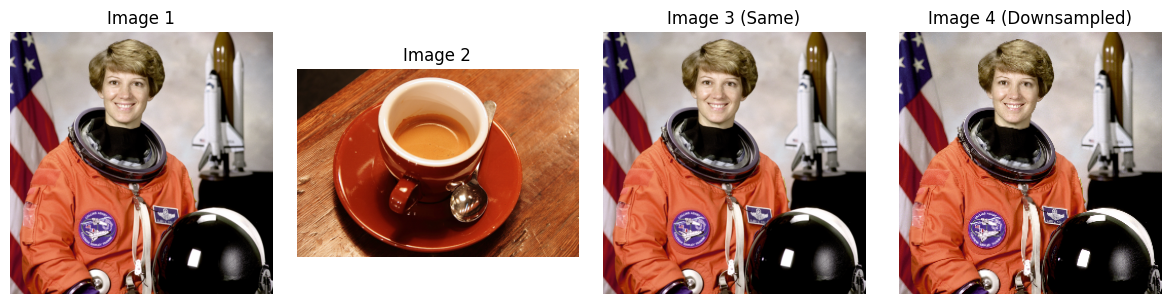

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte
from scipy.spatial import distance

# Fungsi untuk menghitung histogram RGB gabungan
def calculate_rgb_histogram(image, bins=16):
    img_uint8 = img_as_ubyte(image)
    hist_r, _ = np.histogram(img_uint8[:, :, 0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(img_uint8[:, :, 1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(img_uint8[:, :, 2].ravel(), bins=bins, range=(0, 256))
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))
    hist_combined = hist_combined.astype(float) / np.sum(hist_combined)
    return hist_combined

# 1. Muat dua citra berwarna
try:
    image1 = data.astronaut()
    image2 = data.coffee()             # Citra yang berbeda
    image3 = data.astronaut()          # Citra yang sama
    image4 = image1[::2, ::2, :]       # Versi downsampled dari image1
except Exception as e:
    print(f"Gagal memuat data skimage: {e}. Membuat citra dummy.")
    image1 = np.random.rand(100, 100, 3)
    image2 = np.random.rand(100, 100, 3) * 0.5
    image3 = image1.copy()
    image4 = image1[::2, ::2, :]

# 2. Hitung histogram untuk setiap citra
hist1 = calculate_rgb_histogram(image1)
hist2 = calculate_rgb_histogram(image2)
hist3 = calculate_rgb_histogram(image3)
hist4 = calculate_rgb_histogram(image4)

# 3. Hitung Cosine Similarity (1 - Cosine Distance)
sim_12 = 1 - distance.cosine(hist1, hist2)
sim_13 = 1 - distance.cosine(hist1, hist3)
sim_14 = 1 - distance.cosine(hist1, hist4)

# 4. Tampilkan hasil
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 2 (Coffee): {sim_12:.4f}")
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 3 (Astronaut): {sim_13:.4f}")
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 4 (Astronaut Downsampled): {sim_14:.4f}")

# 5. Visualisasi
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(image1)
axes[0].set_title('Image 1')
axes[0].axis('off')

axes[1].imshow(image2)
axes[1].set_title('Image 2')
axes[1].axis('off')

axes[2].imshow(image3)
axes[2].set_title('Image 3 (Same)')
axes[2].axis('off')

axes[3].imshow(image4)
axes[3].set_title('Image 4 (Downsampled)')
axes[3].axis('off')

plt.tight_layout()
plt.show()


SSIM (Ref vs Same):     1.0000
SSIM (Ref vs Noisy):    0.2956
SSIM (Ref vs Contrast): 0.9651
SSIM (Ref vs Blurred):  0.8027


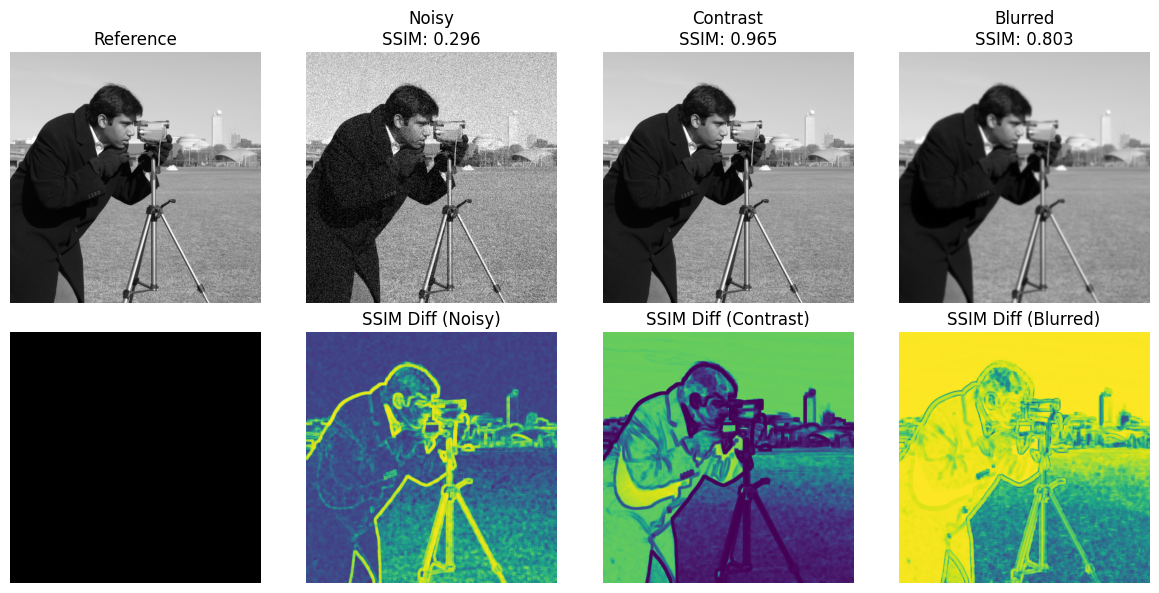

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.util import random_noise
from skimage.filters import gaussian

# 1. Muat citra referensi
image_ref = img_as_float(data.camera())

# 2. Buat beberapa versi citra yang 'terdistorsi'
image_same = image_ref.copy()
image_noisy = random_noise(image_ref, mode='gaussian', var=0.01)
image_contrast = np.clip(image_ref * 0.8, 0, 1)
image_blurred = gaussian(image_ref, sigma=1.5, channel_axis=None)

# 3. Hitung SSIM antara citra referensi dan variasi
data_range = image_ref.max() - image_ref.min()
ssim_same, _ = ssim(image_ref, image_same, data_range=data_range, full=True)
ssim_noisy, diff_noisy = ssim(image_ref, image_noisy, data_range=data_range, full=True)
ssim_contrast, diff_contrast = ssim(image_ref, image_contrast, data_range=data_range, full=True)
ssim_blurred, diff_blurred = ssim(image_ref, image_blurred, data_range=data_range, full=True)

# 4. Tampilkan hasil SSIM
print(f"SSIM (Ref vs Same):     {ssim_same:.4f}")
print(f"SSIM (Ref vs Noisy):    {ssim_noisy:.4f}")
print(f"SSIM (Ref vs Contrast): {ssim_contrast:.4f}")
print(f"SSIM (Ref vs Blurred):  {ssim_blurred:.4f}")

# 5. Visualisasi citra dan peta perbedaan SSIM
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
ax = axes.ravel()

ax[0].imshow(image_ref, cmap='gray')
ax[0].set_title('Reference')
ax[0].axis('off')

ax[1].imshow(image_noisy, cmap='gray')
ax[1].set_title(f'Noisy\nSSIM: {ssim_noisy:.3f}')
ax[1].axis('off')

ax[2].imshow(image_contrast, cmap='gray')
ax[2].set_title(f'Contrast\nSSIM: {ssim_contrast:.3f}')
ax[2].axis('off')

ax[3].imshow(image_blurred, cmap='gray')
ax[3].set_title(f'Blurred\nSSIM: {ssim_blurred:.3f}')
ax[3].axis('off')

ax[4].imshow(np.zeros_like(image_ref), cmap='gray')  # Kosong, untuk layout
ax[4].axis('off')

ax[5].imshow(diff_noisy, cmap='viridis')
ax[5].set_title('SSIM Diff (Noisy)')
ax[5].axis('off')

ax[6].imshow(diff_contrast, cmap='viridis')
ax[6].set_title('SSIM Diff (Contrast)')
ax[6].axis('off')

ax[7].imshow(diff_blurred, cmap='viridis')
ax[7].set_title('SSIM Diff (Blurred)')
ax[7].axis('off')

plt.tight_layout()
plt.show()


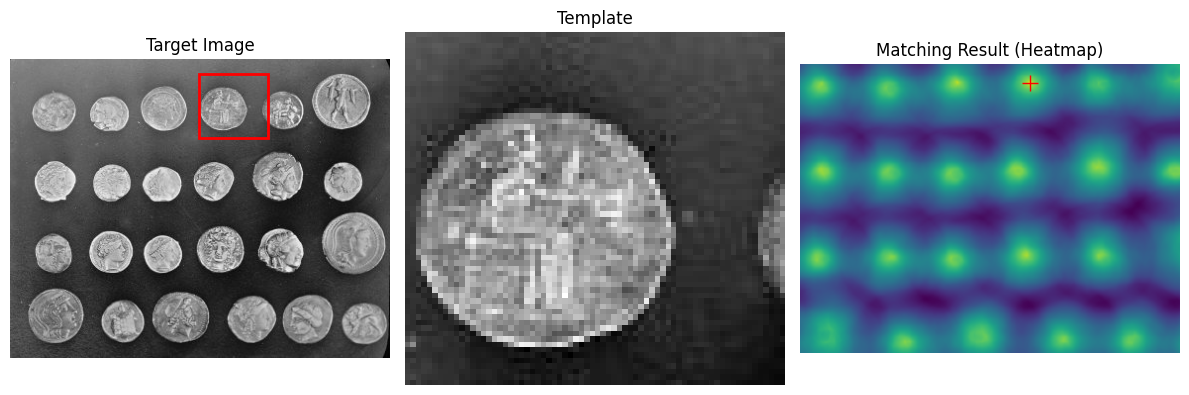

Template ditemukan di koordinat (x,y): (190, 15)


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template
from matplotlib.patches import Rectangle

# 1. Muat citra target dan template
image = data.coins()
template = image[15:80, 190:260]  # Potong salah satu koin sebagai template

# 2. Lakukan pencocokan template
result = match_template(image, template)

# 3. Temukan lokasi terbaik (nilai korelasi tertinggi)
ij = np.unravel_index(np.argmax(result), result.shape)
x, y = ij[::-1]  # ubah ke format (x, y)

# 4. Visualisasi hasil
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# Tampilkan citra asli
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Target Image')
ax[0].axis('off')
# Gambar persegi di lokasi kecocokan
rect = Rectangle((x, y), template.shape[1], template.shape[0],
                 edgecolor='r', facecolor='none', linewidth=2)
ax[0].add_patch(rect)

# Tampilkan template
ax[1].imshow(template, cmap='gray')
ax[1].set_title('Template')
ax[1].axis('off')

# Tampilkan hasil pencocokan (heatmap)
ax[2].imshow(result, cmap='viridis')
ax[2].set_title('Matching Result (Heatmap)')
ax[2].axis('off')
ax[2].plot(x, y, 'r+', markersize=12)  # Titik pusat pencocokan terbaik

plt.tight_layout()
plt.show()

print(f"Template ditemukan di koordinat (x,y): ({x}, {y})")


Memproses database citra...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval (semakin ke kanan, semakin tidak mirip):
Rank 1: chelsea (Distance: 0.000)
Rank 2: coins (Distance: 0.288)
Rank 3: coffee (Distance: 0.359)
Rank 4: astronaut (Distance: 0.461)
Rank 5: camera (Distance: 0.602)


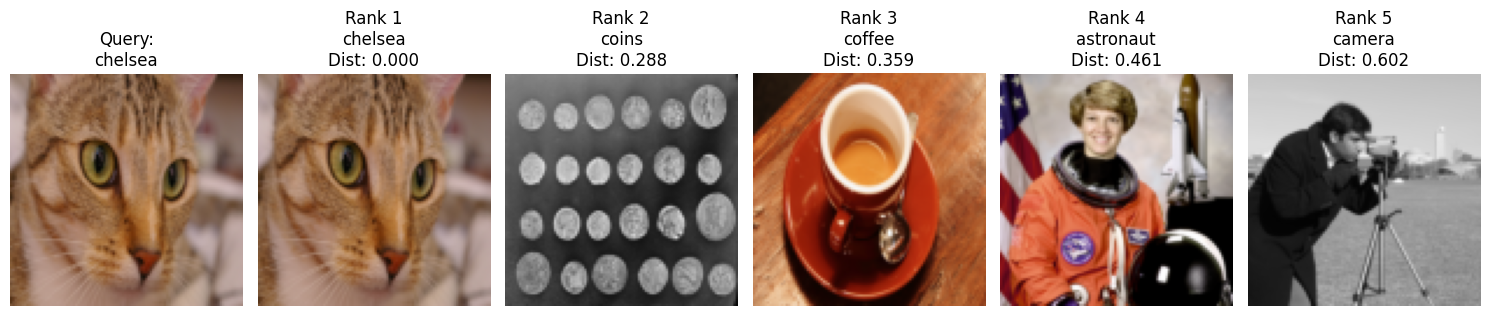

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform, img_as_ubyte
from scipy.spatial import distance

# Fungsi hitung histogram RGB
def calculate_rgb_histogram(image, bins=16):
    if image.dtype == float:
        image = img_as_ubyte(image)  # Konversi ke uint8 jika perlu
    hist_r, _ = np.histogram(image[:, :, 0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(image[:, :, 1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(image[:, :, 2].ravel(), bins=bins, range=(0, 256))
    hist_combined = np.concatenate((hist_r, hist_g, hist_b)).astype(float)
    hist_sum = np.sum(hist_combined)
    if hist_sum > 0:
        hist_combined /= hist_sum
    return hist_combined

# 1. Database gambar dan histogramnya
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_hists = []

print("Memproses database citra...")
for name in image_db_names:
    try:
        img = getattr(data, name)()
        if img.ndim == 2:  # grayscale -> RGB
            img = color.gray2rgb(img)
        img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
        database_images.append(img_resized)
        database_hists.append(calculate_rgb_histogram(img_resized))
        print(f"- {name} diproses.")
    except Exception as e:
        print(f"Error memproses {name}: {e}")

# 2. Ambil satu citra sebagai query (contoh: 'chelsea')
query_image_name = "chelsea"
query_index = image_db_names.index(query_image_name)
query_image = database_images[query_index]
query_hist = database_hists[query_index]

# 3. Hitung Cosine Distance dengan semua gambar di database
distances = []
for hist in database_hists:
    dist = distance.cosine(query_hist, hist)
    distances.append(dist)

# 4. Urutkan hasil
sorted_indices = np.argsort(distances)

# 5. Tampilkan hasil pencarian
num_results_to_show = len(database_images)
fig, axes = plt.subplots(1, num_results_to_show + 1, figsize=(15, 3))

# Tampilkan query
axes[0].imshow(query_image)
axes[0].set_title(f"Query:\n{query_image_name}")
axes[0].axis('off')

print("\nHasil Retrieval (semakin ke kanan, semakin tidak mirip):")
for i, idx in enumerate(sorted_indices):
    img_rank = i + 1
    ax = axes[img_rank]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {img_rank}\n{image_db_names[idx]}\nDist: {distances[idx]:.3f}")
    ax.axis('off')
    print(f"Rank {img_rank}: {image_db_names[idx]} (Distance: {distances[idx]:.3f})")

plt.tight_layout()
plt.show()


Memproses database citra (rata-rata warna)...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval (semakin ke kanan, semakin tidak mirip) - Fitur Rata-rata Warna:
Rank 1: chelsea (Distance: 0.000)
Rank 2: astronaut (Distance: 12.776)
Rank 3: coffee (Distance: 45.003)
Rank 4: camera (Distance: 49.416)
Rank 5: coins (Distance: 53.809)


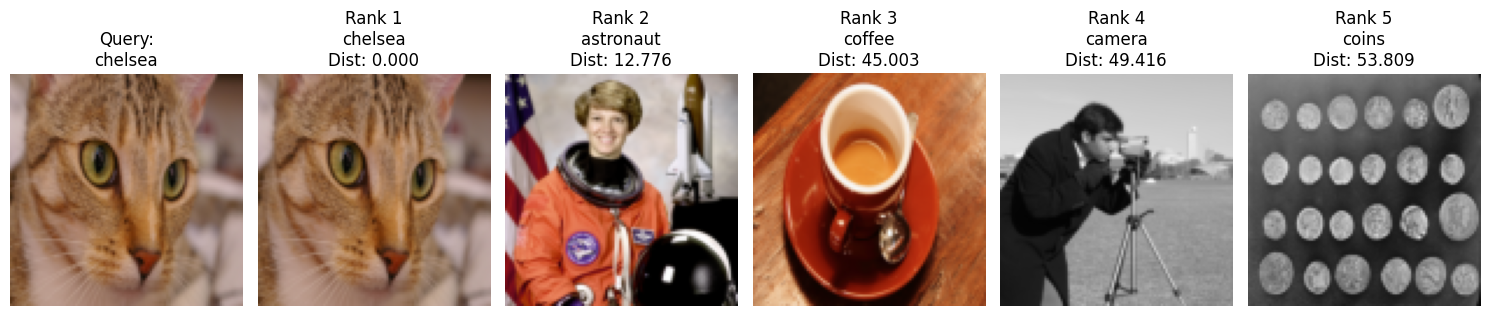


Perbandingan Hasil:
----------------------------------------------------
Query: chelsea

Hasil dengan Histogram Warna (Cosine Distance):
Rank 1: chelsea (Distance: 0.000)
Rank 2: coins (Distance: 0.288)
Rank 3: coffee (Distance: 0.359)
Rank 4: astronaut (Distance: 0.461)
Rank 5: camera (Distance: 0.602)

Hasil dengan Rata-rata Warna (Euclidean Distance):
Rank 1: chelsea (Distance: 0.000)
Rank 2: astronaut (Distance: 12.776)
Rank 3: coffee (Distance: 45.003)
Rank 4: camera (Distance: 49.416)
Rank 5: coins (Distance: 53.809)


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform, img_as_ubyte
from scipy.spatial import distance

# Fungsi hitung rata-rata warna RGB
def calculate_mean_rgb(image):
    if image.dtype == float:
        image = img_as_ubyte(image)  # Konversi ke uint8 jika perlu
    mean_r = np.mean(image[:, :, 0])
    mean_g = np.mean(image[:, :, 1])
    mean_b = np.mean(image[:, :, 2])
    return np.array([mean_r, mean_g, mean_b])

# 1. Database gambar dan fitur rata-rata warnanya
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_mean_colors = []

print("Memproses database citra (rata-rata warna)...")
for name in image_db_names:
    try:
        img = getattr(data, name)()
        if img.ndim == 2:  # grayscale -> RGB
            img = color.gray2rgb(img)
        img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
        database_images.append(img_resized)
        database_mean_colors.append(calculate_mean_rgb(img_resized))
        print(f"- {name} diproses.")
    except Exception as e:
        print(f"Error memproses {name}: {e}")

# 2. Ambil satu citra sebagai query (contoh: 'chelsea')
query_image_name = "chelsea"
query_index = image_db_names.index(query_image_name)
query_image = database_images[query_index]
query_mean_color = database_mean_colors[query_index]

# 3. Hitung Euclidean Distance dengan semua gambar di database (berdasarkan rata-rata warna)
distances_mean = []
for mean_color in database_mean_colors:
    dist = distance.euclidean(query_mean_color, mean_color)
    distances_mean.append(dist)

# 4. Urutkan hasil berdasarkan jarak Euclidean
sorted_indices_mean = np.argsort(distances_mean)

# 5. Tampilkan hasil pencarian menggunakan fitur rata-rata warna
num_results_to_show = len(database_images)
fig_mean, axes_mean = plt.subplots(1, num_results_to_show + 1, figsize=(15, 3))

# Tampilkan query
axes_mean[0].imshow(query_image)
axes_mean[0].set_title(f"Query:\n{query_image_name}")
axes_mean[0].axis('off')

print("\nHasil Retrieval (semakin ke kanan, semakin tidak mirip) - Fitur Rata-rata Warna:")
for i, idx in enumerate(sorted_indices_mean):
    img_rank = i + 1
    ax = axes_mean[img_rank]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {img_rank}\n{image_db_names[idx]}\nDist: {distances_mean[idx]:.3f}")
    ax.axis('off')
    print(f"Rank {img_rank}: {image_db_names[idx]} (Distance: {distances_mean[idx]:.3f})")

plt.tight_layout()
plt.show()

# Perbandingan dengan hasil histogram (kode sebelumnya perlu dijalankan terlebih dahulu)
print("\nPerbandingan Hasil:")
print("----------------------------------------------------")
print(f"Query: {query_image_name}")
print("\nHasil dengan Histogram Warna (Cosine Distance):")
for i, idx in enumerate(sorted_indices):
    print(f"Rank {i+1}: {image_db_names[idx]} (Distance: {distances[idx]:.3f})")

print("\nHasil dengan Rata-rata Warna (Euclidean Distance):")
for i, idx in enumerate(sorted_indices_mean):
    print(f"Rank {i+1}: {image_db_names[idx]} (Distance: {distances_mean[idx]:.3f})")

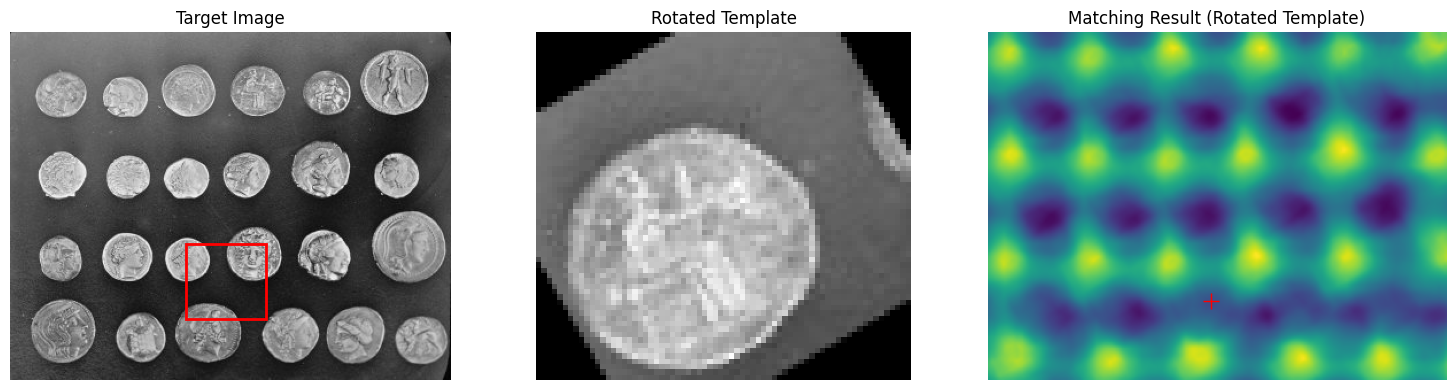

Template yang dirotasi ditemukan di koordinat (y, x): (153, 184)
Perhatikan apakah lokasi ini sesuai dengan koin yang sebenarnya.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform
from skimage.feature import match_template
from matplotlib.patches import Rectangle

# Muat citra target dan template (ambil dari kode Praktikum 4)
image = data.coins()
template = image[15:80, 190:260]

# Rotasi template
rotated_template = transform.rotate(template, angle=30, resize=False)

# Lakukan pencocokan template dengan template yang dirotasi
result_rotated = match_template(image, rotated_template)

# Temukan lokasi terbaik (nilai korelasi tertinggi)
ij_rotated = np.unravel_index(np.argmax(result_rotated), result_rotated.shape)
x_rotated, y_rotated = ij_rotated[::-1]

# Visualisasi hasil
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Tampilkan citra asli
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Target Image')
rect = Rectangle((y_rotated, x_rotated), rotated_template.shape[1], rotated_template.shape[0], edgecolor='r', facecolor='none', linewidth=2)
axes[0].add_patch(rect)
axes[0].axis('off')

# Tampilkan template yang dirotasi
axes[1].imshow(rotated_template, cmap='gray')
axes[1].set_title('Rotated Template')
axes[1].axis('off')

# Tampilkan hasil pencocokan (heatmap)
axes[2].imshow(result_rotated, cmap='viridis')
axes[2].set_title('Matching Result (Rotated Template)')
axes[2].plot(y_rotated, x_rotated, 'r+', markersize=12)
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Template yang dirotasi ditemukan di koordinat (y, x): ({y_rotated}, {x_rotated})")
print("Perhatikan apakah lokasi ini sesuai dengan koin yang sebenarnya.")

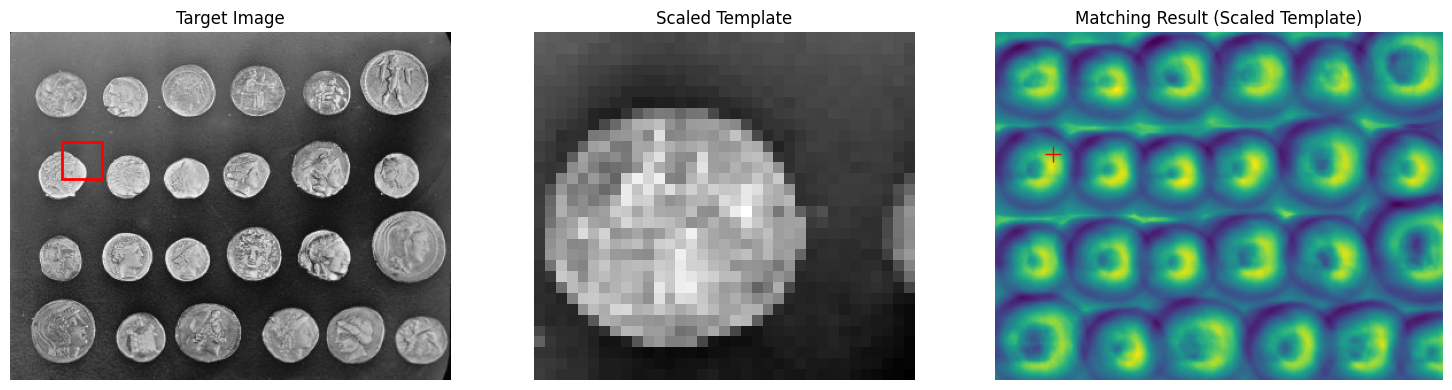

Template yang diubah ukurannya ditemukan di koordinat (y, x): (45, 95)
Perhatikan apakah lokasi ini sesuai dengan koin yang sebenarnya.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform
from skimage.feature import match_template
from matplotlib.patches import Rectangle

# Muat citra target dan template (ambil dari kode Praktikum 4)
image = data.coins()
template = image[15:80, 190:260]

# Ubah ukuran template (misalnya, perkecil)
scaled_template = transform.resize(template, (template.shape[0] // 2, template.shape[1] // 2), anti_aliasing=True)

# Lakukan pencocokan template dengan template yang diubah ukurannya
result_scaled = match_template(image, scaled_template)

# Temukan lokasi terbaik (nilai korelasi tertinggi)
ij_scaled = np.unravel_index(np.argmax(result_scaled), result_scaled.shape)
x_scaled, y_scaled = ij_scaled[::-1]

# Visualisasi hasil
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Tampilkan citra asli
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Target Image')
rect = Rectangle((y_scaled, x_scaled), scaled_template.shape[1], scaled_template.shape[0], edgecolor='r', facecolor='none', linewidth=2)
axes[0].add_patch(rect)
axes[0].axis('off')

# Tampilkan template yang diubah ukurannya
axes[1].imshow(scaled_template, cmap='gray')
axes[1].set_title('Scaled Template')
axes[1].axis('off')

# Tampilkan hasil pencocokan (heatmap)
axes[2].imshow(result_scaled, cmap='viridis')
axes[2].set_title('Matching Result (Scaled Template)')
axes[2].plot(y_scaled, x_scaled, 'r+', markersize=12)
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Template yang diubah ukurannya ditemukan di koordinat (y, x): ({y_scaled}, {x_scaled})")
print("Perhatikan apakah lokasi ini sesuai dengan koin yang sebenarnya.")